# **Marketing-roi-analysis using Simple Linear Regression**

### **Importing Libraries**

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

## **Loading dataset**

In [2]:
df = pd.read_csv('Marketing ROI.csv')
df.head()

,TV,Radio,Social_Media,Sales
0,16.0,6.566231,2.907983,54.732757
1,13.0,9.237765,2.409567,46.677897
2,41.0,15.886446,2.913410,150.177829
3,83.0,30.020028,6.922304,298.246340
4,15.0,8.437408,1.405998,56.594181


## **Data Cleaning and Exploration**

Viewing data shape

In [3]:
df.shape

(4572, 4)

Viewing data info

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4572 entries, 0 to 4571
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            4562 non-null   float64
 1   Radio         4568 non-null   float64
 2   Social_Media  4566 non-null   float64
 3   Sales         4566 non-null   float64
dtypes: float64(4)
memory usage: 143.0 KB


Checking for missing values

In [5]:
df.isna().sum()

TV              10
Radio            4
Social_Media     6
Sales            6
dtype: int64

Handling/Removing missing values

In [6]:
df=df.dropna()

Summary of numeric data

In [7]:
df.describe()

,TV,Radio,Social_Media,Sales
count,4546.000000,4546.000000,4546.000000,4546.000000
mean,54.062912,18.157533,3.323473,192.413332
std,26.104942,9.663260,2.211254,93.019873
min,10.000000,0.000684,0.000031,31.199409
25%,32.000000,10.555355,1.530822,112.434612
50%,53.000000,17.859513,3.055565,188.963678
75%,77.000000,25.640603,4.804919,272.324236
max,100.000000,48.871161,13.981662,364.079751


Heatmap diagram

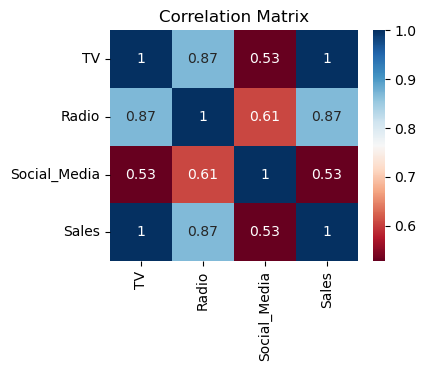

This helps identify which advertising channel has the strongest relationship with Sales.


In [8]:
plt.figure(figsize=(4,3))

sns.heatmap(df.corr(), annot=True, cmap='RdBu')

plt.title("Correlation Matrix")
plt.show()

print("This helps identify which advertising channel has the strongest relationship with Sales.")

**Scatterplot to assess linear relationship between dataset**

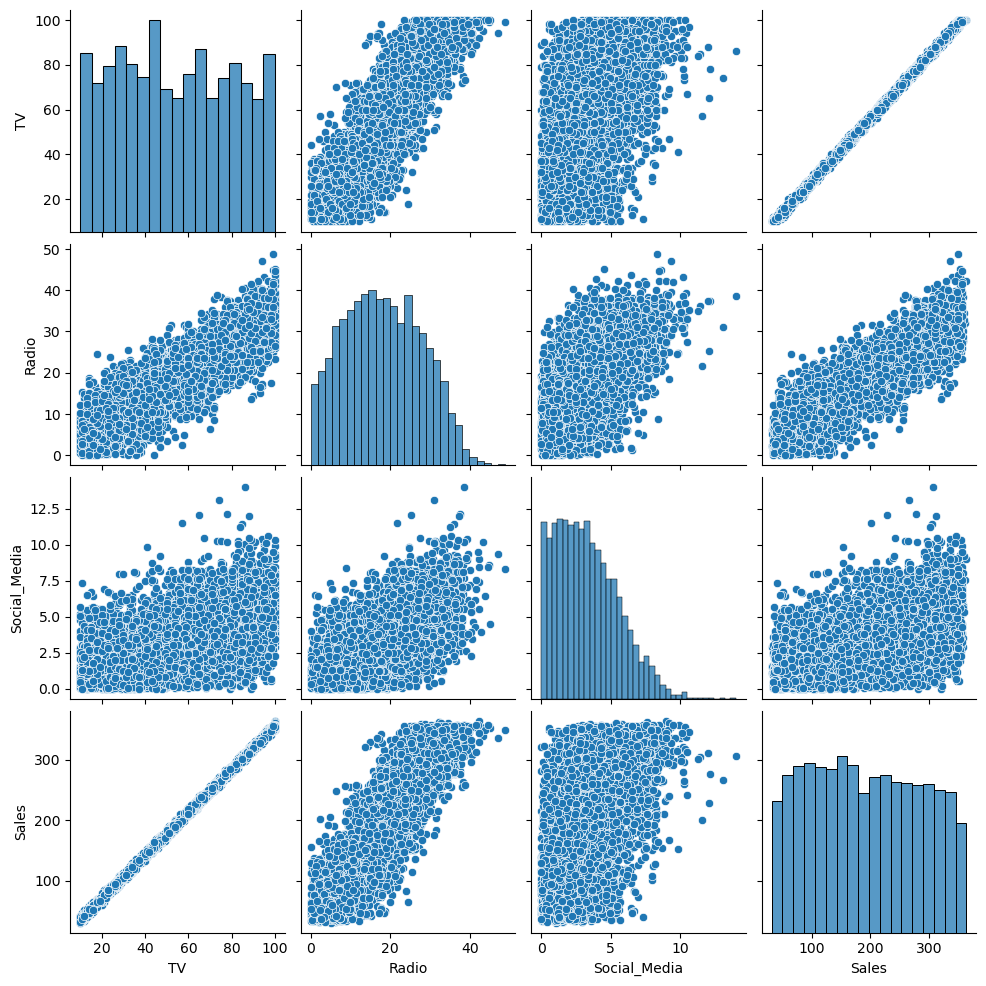

In [9]:
sns.pairplot(df)

**Correlation between variables**

In [10]:
print("Variable      Correlation with Sales")
print("------------------------------------") 
print(" TV                     1.00        ")
print(" Radio                  0.87        ")
print(" Social Media           0.53        ")

print("TV is the best predictor because it has the highest positive correlation with Sales.")

Variable      Correlation with Sales
------------------------------------
 TV                     1.00        
 Radio                  0.87        
 Social Media           0.53        
TV is the best predictor because it has the highest positive correlation with Sales.


## **Building the Simple Linear Regression Model**

Using:

Independent Variable (X) → TV

Dependent Variable (y) → Sales

In [11]:
X = df['TV']
y = df['Sales']

Adding constant

In [12]:
X = sm.add_constant(X)

### **Final formula**

Sales = b(TV) + c

Fitting the model

In [13]:
model = sm.OLS(y, X).fit()

Results

In [14]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 4.517e+06
Date:                Sat, 13 Jun 2026   Prob (F-statistic):               0.00
Time:                        15:58:45   Log-Likelihood:                -11366.
No. Observations:                4546   AIC:                         2.274e+04
Df Residuals:                    4544   BIC:                         2.275e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1325      0.101     -1.317      0.188      -0.330       0.065
TV             3.5615      0.002   2125.272      0.000       3.558       3.565
==============================================================================
Omnibus:                        0.052   Durbin-Watson:                   1.998
Prob(Omnibus):                  0.974   Jarque-Bera (JB):                0.031
Skew:                          -0.001   Prob(JB):                        0.985
Kurtosis:                       3.012   Cond. No.                         138.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### **Predicted Values**

In [15]:
predictions = model.predict(X)

predictions.head()

0     56.851733
1     46.167191
2    145.889585
3    295.473177
4     53.290219
dtype: float64

### **Diagnostic Plots**
These help verify regression assumptions

#### **Linearity Check**

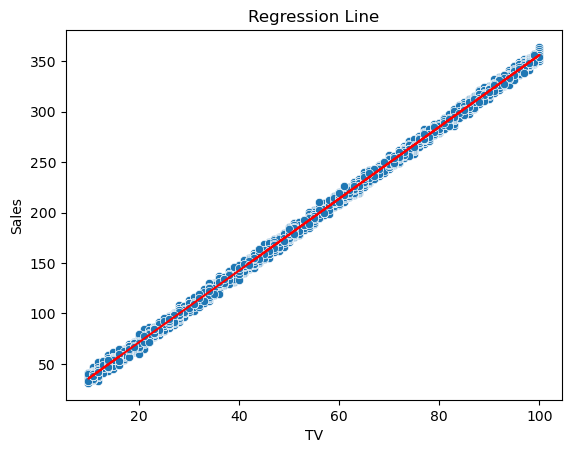

A straight-line trend indicates linearity


In [16]:
sns.scatterplot(x=df['TV'], y=y)
plt.plot(df['TV'], predictions, color='red')

plt.title("Regression Line")
plt.show()
print("A straight-line trend indicates linearity")

### **Residual Plot (Homoscedasticity)**

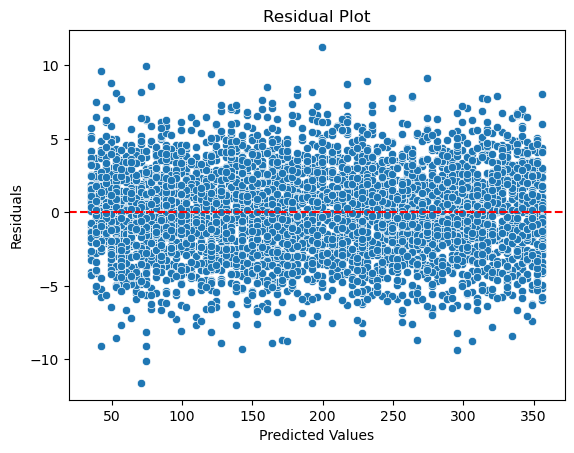

Residuals should appear randomly distributed around zero.


In [17]:
residuals = y - predictions

sns.scatterplot(x=predictions, y=residuals)

plt.axhline(y=0, color='red', linestyle='--')

plt.title("Residual Plot")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.show()
print("Residuals should appear randomly distributed around zero.")

### **Normality Check**

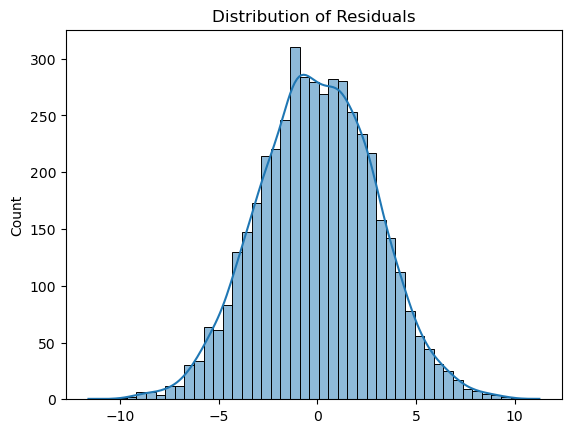

In [18]:
sns.histplot(residuals, kde=True)

plt.title("Distribution of Residuals")
plt.show()

### **Q-Q Plot**

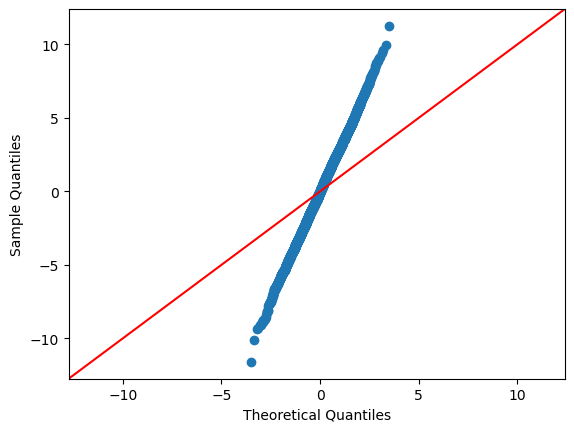

In [19]:
sm.qqplot(residuals, line='45')
plt.show()

### **Recommended Marketing Strategy**

Based on the regression analysis:

- TV advertising has the strongest relationship with Sales.
- The regression model is statistically significant.
- The high R-squared value indicates good predictive strength.
- Diagnostic plots confirm the model assumptions are reasonably satisfied.

### **ROI Recommendation**

The company should allocate a larger percentage of its marketing budget toward TV advertising because it produces the strongest measurable impact on sales revenue.